In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.preprocessing import StandardScaler
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

#load dataset
df = pd.read_csv("train_raw.csv")
print(df.shape)
print(xgb.__version__)

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(21263, 82)
3.2.0


In [2]:
X = df.drop(columns=["critical_temp"])
y = df["critical_temp"]
#train & test data split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(len(X_train),len(X_test))

17010 4253


In [3]:
import joblib
#scalling
scaler = StandardScaler()

#fit only on training data
X_train_scale = scaler.fit_transform(X_train)

#same scaling parameters for test data
X_test_scale = scaler.transform(X_test)

In [ ]:
# ── Train XGBoost on scaled data ──────────────────────────
# Split a small validation set from training data only
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scale, y_train,
    test_size=0.1, random_state=42
)

model = xgb.XGBRegressor(
    n_estimators     = 1000,
    learning_rate    = 0.05,
    max_depth        = 7,
    subsample        = 0.6,
    colsample_bytree = 0.6,
    random_state     = 42,
    n_jobs           = -1,
    objective        = "reg:squarederror"
)
model.fit(
    X_tr, y_tr,
    eval_set = [(X_val, y_val)],  # validation only, no test leakage
    verbose  = False
)

# ── Evaluate ───────────────────────────────────────────────
y_pred = model.predict(X_test_scale)
print(f"Model R² score: {r2_score(y_test, y_pred):.3f}")


Model R² score: 0.932


In [5]:

# ── SHAP on scaled data ────────────────────────────────────
explainer = shap.TreeExplainer(model)

sample_idx = np.random.RandomState(42).choice(
    len(X_train_scale), size=min(2000, len(X_train_scale)), replace=False
)
samples_for_shap = pd.DataFrame(
    X_train_scale[sample_idx],
    columns = X_train.columns   # ✅ scaled + column names preserved
)
shap_value = explainer.shap_values(samples_for_shap)

# ── Feature importance ─────────────────────────────────────
shap_imp = pd.Series(
    np.abs(shap_value).mean(axis=0),
    index = X_train.columns     # ✅ use X_train.columns not X.columns
).sort_values(ascending=False)

top_50_features = shap_imp.head(50).index

print("Top 15 features:\n", shap_imp.head(15))

# ── Step 1: Filter top 50 from UNSCALED data ──────────────
X_top50_train = X_train[top_50_features]   # unscaled DataFrame ✅
X_top50_test  = X_test[top_50_features]    # unscaled DataFrame ✅

# ── Step 2: Save as separate files if needed ──────────────
top50_train = pd.concat([
    X_top50_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
], axis=1)

top50_test = pd.concat([
    X_top50_test.reset_index(drop=True),
    y_test.reset_index(drop=True)
], axis=1)

top50_train.to_csv('top50_train.csv', index=False)  # save ✅
top50_test.to_csv('top50_test.csv',   index=False)  # save ✅

print(top50_train.shape)  # (17010, 51)
print(top50_test.shape)   # (4253, 51)


Top 15 features:
 range_ThermalConductivity          12.856660
range_atomic_radius                 3.225982
wtd_std_ThermalConductivity         2.753781
wtd_gmean_ThermalConductivity       1.879971
wtd_std_ElectronAffinity            1.813773
wtd_mean_ThermalConductivity        1.658969
wtd_mean_Valence                    1.642011
wtd_gmean_Valence                   1.632835
std_atomic_mass                     1.381930
wtd_std_Valence                     1.115506
wtd_entropy_ThermalConductivity     1.004712
mean_Density                        0.998469
gmean_Density                       0.985368
wtd_entropy_Density                 0.890260
wtd_entropy_atomic_mass             0.680999
dtype: float32
(17010, 51)
(4253, 51)


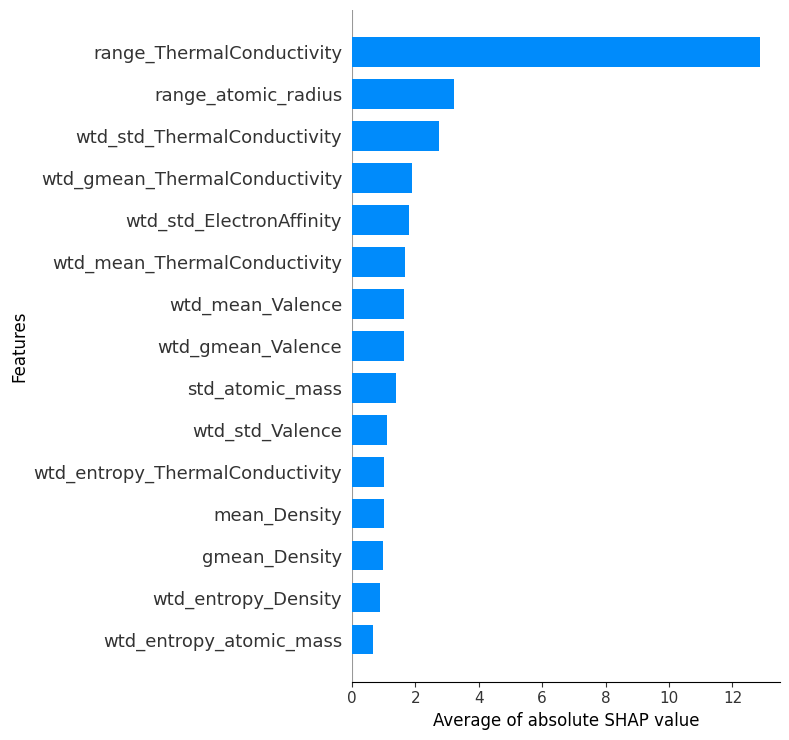

In [6]:
# ── Plot 1: Bar chart ──────────────────────────────────
shap.summary_plot(
    shap_value, samples_for_shap,
    plot_type    = "bar",
    max_display  = 15,
    show         = False
)
plt.xlabel('Average of absolute SHAP value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('shap_bar_81.png', dpi=300, bbox_inches='tight')
plt.show()


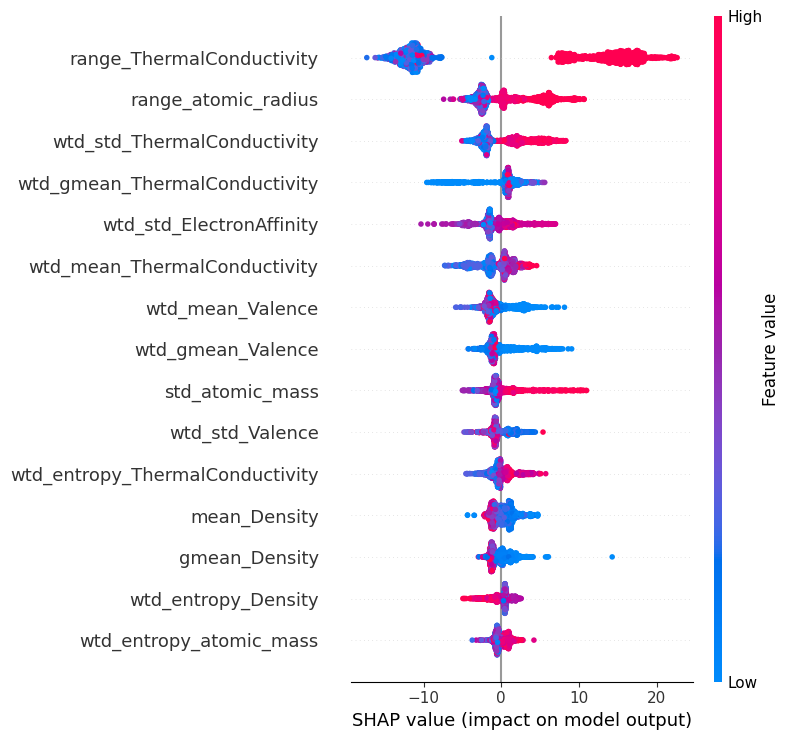

In [8]:

# ── Plot 2: Beeswarm ───────────────────────────────────
shap.summary_plot(
    shap_value, samples_for_shap,
    max_display = 15,
    show        = False
)
plt.tight_layout()
plt.savefig('shap_beeswarm_81.png', dpi=300, bbox_inches='tight')
plt.show()


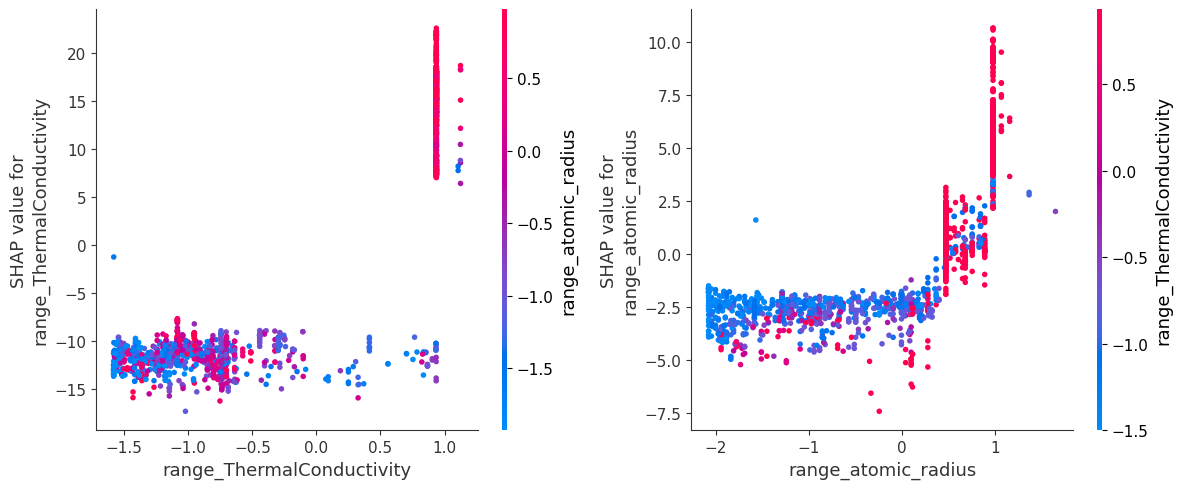

In [10]:

# ── Plot 3: Dependence plots ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
shap.dependence_plot(
    "range_ThermalConductivity", shap_value, samples_for_shap,
    interaction_index = "range_atomic_radius",
    ax=axes[0], show=False
)
shap.dependence_plot(
    "range_atomic_radius", shap_value, samples_for_shap,
    interaction_index = "range_ThermalConductivity",
    ax=axes[1], show=False
)
plt.tight_layout()
plt.savefig('shap_dependence_81.png', dpi=300, bbox_inches='tight')
plt.show()


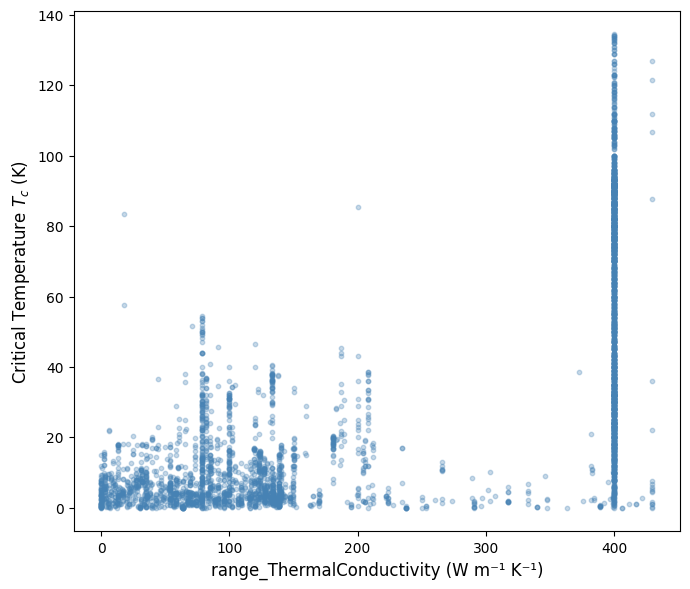

In [9]:
plt.figure(figsize=(7,6))
plt.scatter(X_test['range_ThermalConductivity'],
                y_test, alpha=0.3, s=10, color='steelblue')
plt.xlabel('range_ThermalConductivity (W m⁻¹ K⁻¹)', fontsize=12)
plt.ylabel('Critical Temperature $T_c$ (K)', fontsize=12)
# plt.title('range_ThermalConductivity vs Tc', fontsize=13)
#ensuring clean layout
plt.tight_layout()
#save high resolution image
plt.savefig("thermal vs Tc.png", dpi =1000, bbox_inches = 'tight')
#display
plt.show()

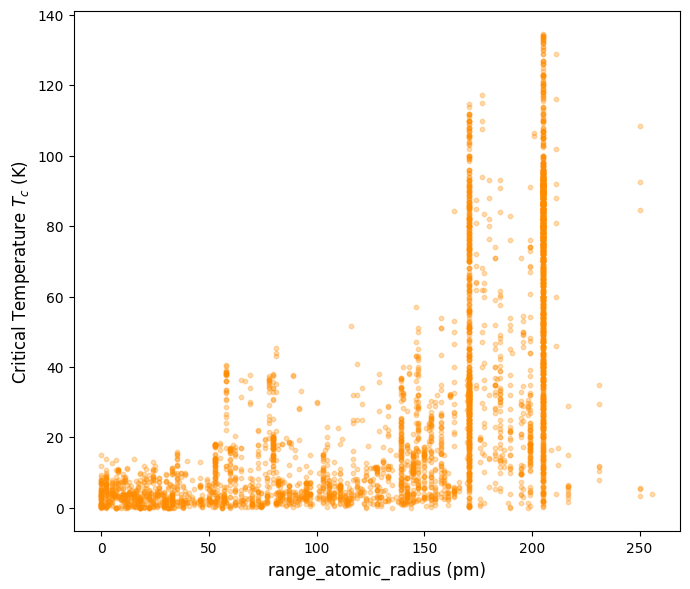

In [8]:
plt.figure(figsize=(7,6))
plt.scatter(X_test['range_atomic_radius'],
                 y_test, alpha=0.3, s=10, color='darkorange')
plt.xlabel('range_atomic_radius (pm)', fontsize=12)
plt.ylabel('Critical Temperature $T_c$ (K)', fontsize=12)
# plt.title('range_ThermalConductivity vs Tc', fontsize=13)
#ensuring clean layout
plt.tight_layout()
#save high resolution image
plt.savefig("atomic vs Tc.png", dpi =1000, bbox_inches = 'tight')
#display
plt.show()